---
format: 
    html:
      toc: true
title: "Bulk RNA Analysis"
author: "Lavinia I Fechete, Stig U Andersen, Mikkel H Schierup, Samuele Soraggi"
title-block-banner: true
---

:::{.callout-note title="Tutorial description"}

This tutorial will cover the steps for performing Differential Gene Expression on the RNA-seq data obtained from Galaxy. At the end of this tutorial you will be able to use `Python` to
    
- Perform preliminary analyses of the RNA-seq results
- Find differentially expressed genes between two conditions using `pydeseq2`

:::


**Load the necessary Python libraries**

In [1]:
from pydeseq2.ds import DeseqStats
from pydeseq2.default_inference import DefaultInference
import glob
import pandas as pd
import os
from rich.pretty import pprint
import pydeseq2 as pds
from pydeseq2.dds import DeseqDataSet
from pydeseq2.utils import load_example_data  # Optional: example data

# PyDESeq2 - Data filtering and Normalization 

We will use the `pydeseq2` package to test for differentially expressed genes between our Control and Treatment Samples. You can read more about the pydeseq2 package and its functionalities [here](https://pydeseq2.readthedocs.io/en/latest/). This exercise largely follows their documentation. 


## File processing

The data for this exercise comes from the 12 tabular files with Reads per Gene counts generated by STAR Mapping in the `raw-data alignment` part of this course.
We want to create a table where each column is a sample, and the content of the table are the read counts from STAR. We must merge the 12 files with Reads per Gene information into a single file.

* If you aligned datasets in the first notebook with jupyterlab, then you will find the files - 12 files precisely - using the following command:

In [2]:
# Get the list of sample files and sort them
samples = sorted(glob.glob("results/STAR_output/*_align_contigs_1_2/*ReadsPerGene.out.tab"))
pprint(samples)

# Read and combine counts
read_counts_list = []
for sample in samples:
    df = pd.read_csv(sample, sep="\t", header=None, skiprows=4)
    read_counts_list.append(df[[1]])  # index 1 = unstranded counts (column 2 in STAR's 1-indexed output)

# Concatenate all counts side by side (cbind equivalent)
read_counts = pd.concat(read_counts_list, axis=1)

# Optionally: set gene names from the first column of the first file
genes = list(pd.read_csv(samples[0], sep="\t", header=None, skiprows=4)[0])
read_counts.index = genes

# Optionally: assign sample names to columns
sample_names = [os.path.basename(path).replace("ReadsPerGene.out.tab", "") for path in samples]
read_counts.columns = sample_names

[
│   'results/STAR_output/S10_align_contigs_1_2/S10_1_1ReadsPerGene.out.tab',
│   'results/STAR_output/S10_align_contigs_1_2/S10_1_2ReadsPerGene.out.tab',
│   'results/STAR_output/S10_align_contigs_1_2/S10_1_3ReadsPerGene.out.tab',
│   'results/STAR_output/S10_align_contigs_1_2/S10_2_1ReadsPerGene.out.tab',
│   'results/STAR_output/S10_align_contigs_1_2/S10_2_2ReadsPerGene.out.tab',
│   'results/STAR_output/S10_align_contigs_1_2/S10_2_3ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_1_1ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_1_2ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_1_3ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_2_1ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_2_2ReadsPerGene.out.tab',
│   'results/STAR_output/TI_align_contigs_1_2/TI_2_3ReadsPerGene.out.tab'
]

In [4]:
read_counts.head()

,S10_1_1,S10_1_2,S10_1_3,S10_2_1,S10_2_2,S10_2_3,TI_1_1,TI_1_2,TI_1_3,TI_2_1,TI_2_2,TI_2_3
g175,143,226,227,217,206,193,234,205,198,221,206,165
g176,17,12,15,8,14,18,29,19,30,6,11,23
g177,0,0,0,0,0,0,0,0,0,0,0,0
g178,0,0,0,0,0,0,0,0,2,2,1,2
g179,0,0,0,0,0,0,0,0,0,0,0,0


The data frame has genes as rows and samples as columns and stores the gene expression counts (value representing the total number of sequence reads that originated from a particular gene in a sample) for each of the 12 samples. This data frame should have 12 columns and 366 rows.

Load the metadata table, which contains information about each of the 12 RNA-seq samples: treatment (`Condition`), genotype, and replicate.

Note that the order of the rows in the Metadata table should be the same as the columns in the Read_counts file generated above — `pydeseq2` uses these to align counts with the correct sample information.

In order to aid the following steps, we will create a Group for each sample (a new column in the metadata) based on the Genotype&Condition of each sample and assign the three replicates to this group.

In [3]:
# Read the metadata CSV, using ";" as separator and first column as index
metadata = pd.read_csv("../Data/Clover_Data/metadata.csv", sep=";", index_col=0)

# Create 'Group' column by combining 'Genotype' and 'Condition' columns
metadata["Group"] = metadata["Genotype"].astype(str) + "_" + metadata["Condition"].astype(str)

# Display updated metadata
pprint("Metadata after adding group")
metadata

'Metadata after adding group'

,Condition,Genotype,Replicate,Group
Sample,,,,
S10_1_1,Control,S10,1,S10_Control
S10_1_2,Control,S10,2,S10_Control
S10_1_3,Control,S10,3,S10_Control
S10_2_1,Treatment,S10,1,S10_Treatment
S10_2_2,Treatment,S10,2,S10_Treatment
S10_2_3,Treatment,S10,3,S10_Treatment
TI_1_1,Control,Tienshan,1,Tienshan_Control
TI_1_2,Control,Tienshan,2,Tienshan_Control
TI_1_3,Control,Tienshan,3,Tienshan_Control


## Create the annotated data object for pydeseq2

We combine the read counts and the metadata into a `DeseqDataSet` object, which stores the count matrix together with sample metadata and is used for all downstream analysis steps in `pydeseq2`.

Note that genes with zero counts across all samples are removed before creating the object.

In [4]:
# Optional: remove genes with all zero counts (as remove.zeros=TRUE in edgeR)
read_counts_filtered = read_counts[(read_counts > 0).sum(axis=1) > 0]

# Relevel condition so that 'Control' is the reference level
metadata["Condition"] = pd.Categorical(metadata["Condition"], categories=["Control"] + 
                                       [c for c in metadata["Condition"].unique() if c != "Control"],
                                       ordered=True)

inference = DefaultInference(n_cpus=2)

# Create DESeq2 dataset
dds = DeseqDataSet(
    counts=read_counts_filtered.astype(int).T,    # DESeq2 expects integer counts
    metadata=metadata[["Condition", "Genotype", "Group"]],  # include relevant columns
    design="~Group",  # use Group as main design factor
    inference=inference
)

# Check the object
dds

AnnData object with n_obs × n_vars = 12 × 267
    obs: 'Condition', 'Genotype', 'Group'
    obsm: 'design_matrix'

In [5]:
# Count matrix (samples × genes)
dds.X

array([[143,  17,   0, ...,   0,   1,  80],
       [226,  12,   0, ...,   5,   2, 107],
       [227,  15,   0, ...,   0,   2, 120],
       ...,
       [221,   6,   2, ...,   1,   3,  96],
       [206,  11,   1, ...,   0,   3, 105],
       [165,  23,   2, ...,   0,   0, 105]])

In [6]:
# the container — lists all stored matrices
dds.obsm

AxisArrays with keys: design_matrix

In [7]:
# the actual matrix — rows=samples, cols=groups
dds.obsm['design_matrix']

,Intercept,Group[T.S10_Treatment],Group[T.Tienshan_Control],Group[T.Tienshan_Treatment]
Sample,,,,
S10_1_1,1.0,0,0,0
S10_1_2,1.0,0,0,0
S10_1_3,1.0,0,0,0
S10_2_1,1.0,1,0,0
S10_2_2,1.0,1,0,0
S10_2_3,1.0,1,0,0
TI_1_1,1.0,0,1,0
TI_1_2,1.0,0,1,0
TI_1_3,1.0,0,1,0


In [8]:
# Sample metadata — one row per sample with Condition, Genotype, and Group columns
dds.obs

,Condition,Genotype,Group
Sample,,,
S10_1_1,Control,S10,S10_Control
S10_1_2,Control,S10,S10_Control
S10_1_3,Control,S10,S10_Control
S10_2_1,Treatment,S10,S10_Treatment
S10_2_2,Treatment,S10,S10_Treatment
S10_2_3,Treatment,S10,S10_Treatment
TI_1_1,Control,Tienshan,Tienshan_Control
TI_1_2,Control,Tienshan,Tienshan_Control
TI_1_3,Control,Tienshan,Tienshan_Control


In [9]:
# Gene metadata — one row per gene; stores dispersion and fitted values after dds.deseq2()
dds.var

""
g175
g176
g178
g180
g181
...
g169
g170
g171
g172


In [10]:
# Gene-level matrices — stores per-gene model coefficients (LFC) after fitting (no gene-level matrices have been computed yet)
dds.varm

AxisArrays with keys: 

## Preliminary data analysis

This is not part of the actual differential gene expression analysis but is helpful for data exploration and quality assessment.

We will create a PCA plot of the samples to assess differences between genotypes and conditions, and to check that replicates cluster together. The counts are log-transformed (log(x+1)) before PCA to reduce the influence of highly expressed genes.

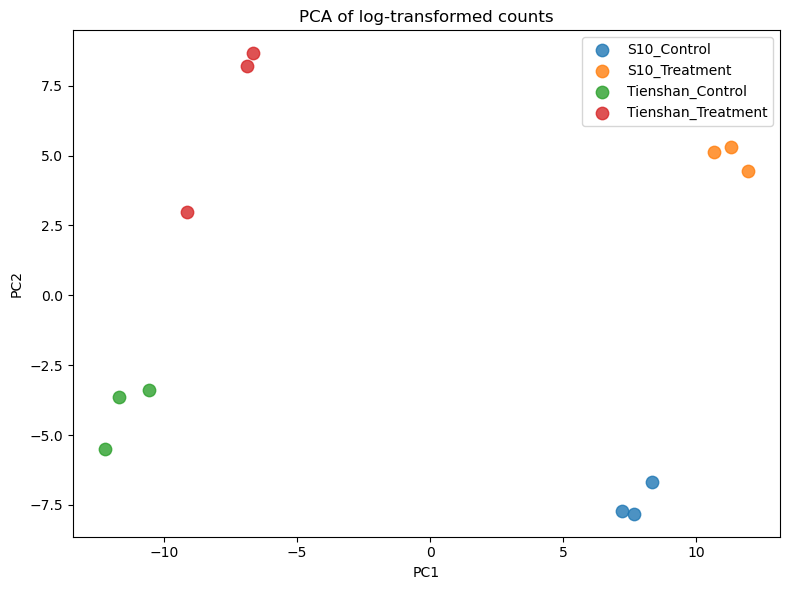

In [11]:
from sklearn.decomposition import PCA
import matplotlib.pyplot as plt
import numpy as np

X_reduced = PCA(n_components=2).fit_transform(np.log1p(dds.X))

groups = dds.obs["Group"].unique()
colors = plt.cm.tab10.colors

plt.figure(figsize=(8, 6))
for i, group in enumerate(groups):
    mask = dds.obs["Group"] == group
    plt.scatter(X_reduced[mask, 0], X_reduced[mask, 1],
                color=colors[i], label=group, alpha=0.8, s=80)

plt.legend(loc="upper right", shadow=False, scatterpoints=1)
plt.xlabel("PC1")
plt.ylabel("PC2")
plt.title("PCA of log-transformed counts")
plt.tight_layout()
plt.show()

## Filtering the lowly expressed genes
As seen previously, many genes have a low number of read counts in our samples. The genes with very low counts across all libraries provide little evidence for differential expression, thus we should eliminate these genes before the analysis. 
<br>
In `pydeseq2`, low-count filtering is applied internally during model fitting. The basic pre-filtering step already performed above removes genes with zero counts across all samples. Additional filtering (e.g. keeping only genes with at least 10 reads in any group) can be applied manually before creating the `DeseqDataSet`.

## Normalized counts - Exploratory Data analysis
For data analysis purposes normalized log2 counts can be extracted from the DGEList object using the function CPM (counts per million).

We will generate the same plots as for the raw counts in order to compare the data before and after normalization. 

Do the plots for normalized counts look different compared with the plots computed before data filtering and normalization? 

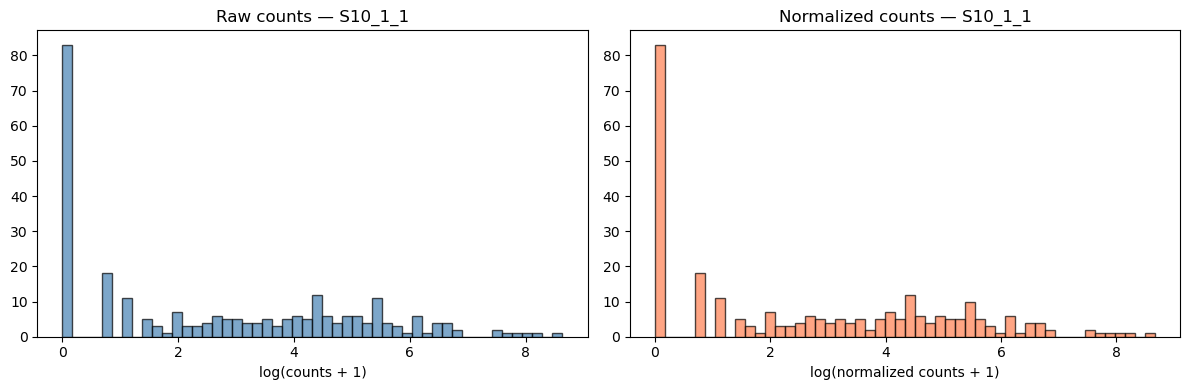

/tmp/43176092/ipykernel_2713152/1867294245.py:24: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[0].boxplot(log_raw.T, labels=sample_names)
/tmp/43176092/ipykernel_2713152/1867294245.py:28: MatplotlibDeprecationWarning: The 'labels' parameter of boxplot() has been renamed 'tick_labels' since Matplotlib 3.9; support for the old name will be dropped in 3.11.
  axes[1].boxplot(log_norm.T, labels=sample_names)


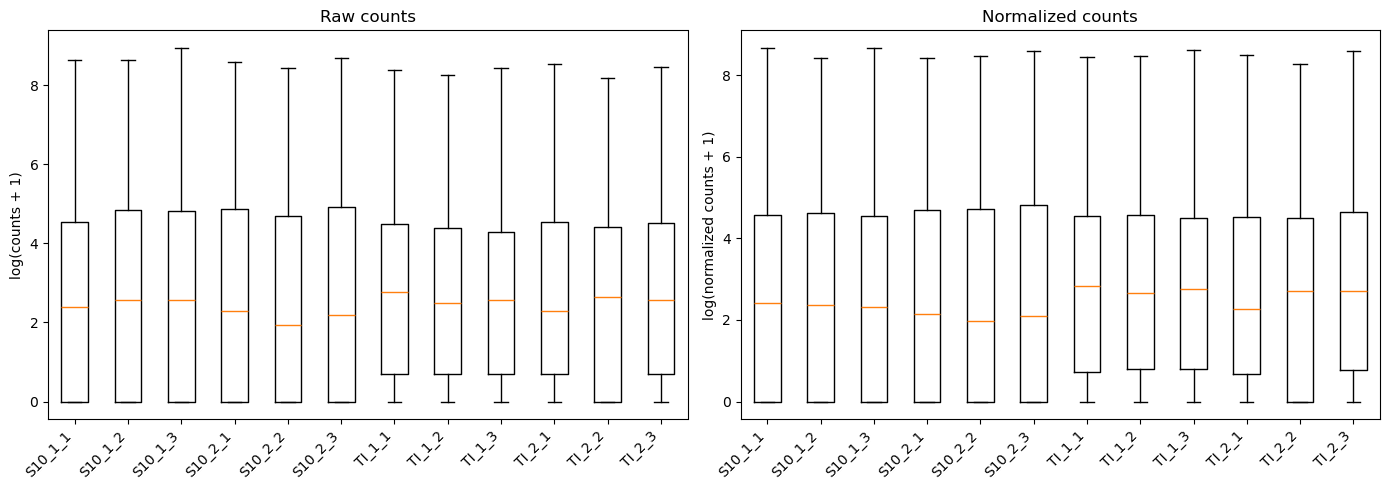

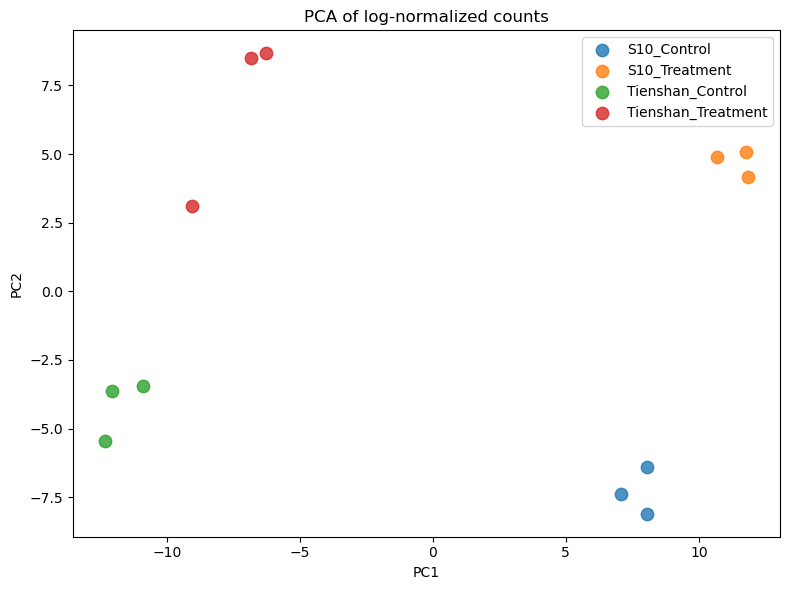

In [12]:
import matplotlib.pyplot as plt
import numpy as np
from sklearn.decomposition import PCA

# Compute normalized counts using DESeq2's median-of-ratios method
norm_counts = pds.preprocessing.deseq2_norm(dds.X)[0]
log_norm = np.log1p(norm_counts)
log_raw = np.log1p(dds.X)

# Histogram: raw vs normalized for one sample (S10_1_1)
fig, axes = plt.subplots(1, 2, figsize=(12, 4))
axes[0].hist(log_raw[0], bins=50, color='steelblue', edgecolor='black', alpha=0.7)
axes[0].set_xlabel('log(counts + 1)')
axes[0].set_title('Raw counts — S10_1_1')
axes[1].hist(log_norm[0], bins=50, color='coral', edgecolor='black', alpha=0.7)
axes[1].set_xlabel('log(normalized counts + 1)')
axes[1].set_title('Normalized counts — S10_1_1')
plt.tight_layout()
plt.show()

# Boxplot: all 12 samples side by side
sample_names = list(dds.obs_names)
fig, axes = plt.subplots(1, 2, figsize=(14, 5))
axes[0].boxplot(log_raw.T, labels=sample_names)
axes[0].set_xticklabels(sample_names, rotation=45, ha='right')
axes[0].set_ylabel('log(counts + 1)')
axes[0].set_title('Raw counts')
axes[1].boxplot(log_norm.T, labels=sample_names)
axes[1].set_xticklabels(sample_names, rotation=45, ha='right')
axes[1].set_ylabel('log(normalized counts + 1)')
axes[1].set_title('Normalized counts')
plt.tight_layout()
plt.show()

# PCA of normalized counts — compare with the raw-counts PCA above
X_reduced_norm = PCA(n_components=2).fit_transform(log_norm)
groups = dds.obs['Group'].unique()
colors = plt.cm.tab10.colors
plt.figure(figsize=(8, 6))
for i, group in enumerate(groups):
    mask = dds.obs['Group'] == group
    plt.scatter(X_reduced_norm[mask, 0], X_reduced_norm[mask, 1],
                color=colors[i], label=group, alpha=0.8, s=80)
plt.legend(loc='upper right', shadow=False, scatterpoints=1)
plt.xlabel('PC1')
plt.ylabel('PC2')
plt.title('PCA of log-normalized counts')
plt.tight_layout()
plt.show()

# PyDESeq2 - Testing for Differentially expressed genes (DEGs)

We now test for differentially expressed genes using `pydeseq2`, which fits a Generalized Linear Model (GLM) with a negative binomial distribution. Normalization, dispersion estimation, and model fitting are all handled automatically by `dds.deseq2()`.

In `pydeseq2`, the design matrix is constructed automatically from the `design` formula specified when creating the `DeseqDataSet` (e.g. `"~Group"`). You can inspect it via `dds.obsm['design_matrix']`. The samples belonging to each group are assigned indicator values in this matrix.

For pairwise comparisons between groups, `pydeseq2` uses the `contrast` parameter in `DeseqStats`, which directly specifies the factor name, numerator level, and denominator level. For example:

- `contrast=["Group", "S10_Treatment", "S10_Control"]` tests S10 Treatment vs S10 Control  
- `contrast=["Group", "Tienshan_Treatment", "Tienshan_Control"]` tests Tienshan Treatment vs Tienshan Control  

The combined analysis across both genotypes is done with a separate `DeseqDataSet` using `design="~Condition"`.

In [13]:
# Fit the DESeq2 model — estimates dispersions and LFC for all genes
# Must be run before any DeseqStats call
dds.deseq2()

Using None as control genes, passed at DeseqDataSet initialization


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...
... done in 0.19 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.22 seconds.

Fitting LFCs...
... done in 0.16 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.



The following cell shows the edgeR equivalent steps (commented out). In `pydeseq2`, dispersion estimation and model fitting are both handled automatically inside `dds.deseq2()`, which was already called above.

## DEGs for White clover S10 plants Treatment vs Control

Find DEGs for White clover S10 plants in Treatment condition compared with the Control condition.
We test for differentially expressed genes using `DeseqStats` from `pydeseq2`, which applies a Wald test on the negative binomial GLM coefficients. We specify the contrast of interest and call `summary()` to extract results for all genes.

In [14]:
# Perform statistical test for S10_Treatment vs S10_Control
stat_S10 = DeseqStats(dds, contrast=["Group", "S10_Treatment", "S10_Control"], n_cpus=2)
stat_S10.summary()

# Extract results sorted by adjusted p-value (like topTags)
deg_S10 = stat_S10.results_df.sort_values("padj")


Log2 fold change & Wald test p-value: Group S10_Treatment vs S10_Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
g175   203.177414        0.173182  0.149575  1.157827  0.246935  0.409333
g176    17.580091       -0.040993  0.584867 -0.070090  0.944122  0.976065
g178     0.647614        0.102858  3.932720  0.026154  0.979134       NaN
g180  2642.862488        0.082838  0.320709  0.258295  0.796179  0.866846
g181   553.192011       -0.330205  0.158534 -2.082868  0.037263  0.086790
...           ...             ...       ...       ...       ...       ...
g169     0.223759        1.059009  4.427023  0.239215  0.810939       NaN
g170     0.102188        0.102859  4.920454  0.020904  0.983322       NaN
g171     0.788091        0.169749  4.061462  0.041795  0.966662       NaN
g172     2.417607        1.495964  1.078064  1.387639  0.165247       NaN
g173    97.041848        0.279564  0.286933  0.974318  0.329898  0.489527

[267 rows x 6 columns]


Running Wald tests...
... done in 0.05 seconds.



We have now created a table with certain parameters calculated for each of the genes analysed.

**log2FoldChange** represents the base 2 logarithm of the fold change and shows how much the expression of the gene has changed between the two conditions. A log2FoldChange of 1 means a doubling in the read count between control and treatment samples.
Genes with a log2FoldChange higher than 0 are upregulated while genes with a log2FoldChange lower than 0 are downregulated.
<br>
**baseMean** represents the average normalized count across all samples, reflecting the overall expression level of the gene.

**stat** - the Wald test statistic.

**pvalue** is the raw p-value.

**padj** (The adjusted p-value) is calculated using Benjamini and Hochberg's algorithm. It controls the rate of false positive values under multiple testing. Usually, a threshold of under 5% is set for the adjusted p-value.

The important information for us in this table is stored in the **log2FoldChange** and **padj** columns. The top DE genes have small padj values and large fold changes.

In [15]:
# Filter by adjusted p-value and log2 fold change
deg_S10_filtered = deg_S10[(deg_S10["padj"] < 0.05) & (deg_S10["log2FoldChange"].abs() > 1)].copy()

# Add gene_ID column from index (like rownames_to_column)
deg_S10_filtered.reset_index(inplace=True)
deg_S10_filtered.rename(columns={"index": "gene_ID"}, inplace=True)

# Preview top genes
print(deg_S10_filtered.head())

# Number of genes that passed the filter
print(len(deg_S10_filtered))


  gene_ID     baseMean  log2FoldChange     lfcSE       stat        pvalue  \
0     g39   881.981553        3.606460  0.203645  17.709586  3.536617e-70   
1    g232   193.277430        4.078671  0.325070  12.547067  4.125055e-36   
2      g6   402.525286        2.344256  0.210899  11.115530  1.054230e-28   
3    g350   504.675818        2.073425  0.235501   8.804317  1.316520e-18   
4    g240  1320.136685        1.381037  0.167826   8.228968  1.888325e-16   

           padj  
0  6.507376e-68  
1  3.795051e-34  
2  6.465944e-27  
3  6.055991e-17  
4  6.949035e-15  
50


We can also visualize the selected genes by plotting a Smear plot or a Volcano plot. The Genes that passed the filter are coloured in red, and the top 10 genes with the lowest FDR value are labelled with their gene ID.

We can see that the majority of the genes analysed are either not statistically significant or have a very small logFC.

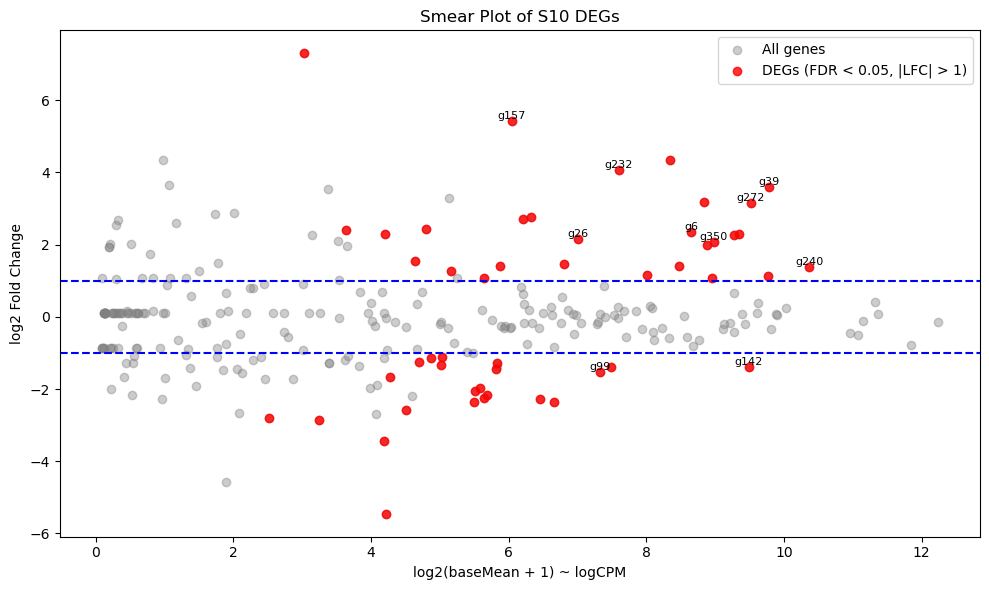

In [16]:
import matplotlib.pyplot as plt
import numpy as np

# Scatter plot of all genes: logCPM vs log2FC
plt.figure(figsize=(10, 6))
plt.scatter(deg_S10["baseMean"].apply(lambda x: np.log2(x + 1)), 
            deg_S10["log2FoldChange"], 
            color="grey", alpha=0.4, label="All genes")

# Highlight filtered DEGs in red
plt.scatter(deg_S10_filtered["baseMean"].apply(lambda x: np.log2(x + 1)), 
            deg_S10_filtered["log2FoldChange"], 
            color="red", alpha=0.8, label="DEGs (FDR < 0.05, |LFC| > 1)")

# Label top 10 DEGs
for i in range(min(10, len(deg_S10_filtered))):
    x = np.log2(deg_S10_filtered.loc[i, "baseMean"] + 1)
    y = deg_S10_filtered.loc[i, "log2FoldChange"]
    label = deg_S10_filtered.iloc[i, 0]
    plt.text(x, y, label, fontsize=8, ha='center', va='bottom')

# Add horizontal lines at logFC ±1
plt.axhline(y=1, color="blue", linestyle="--")
plt.axhline(y=-1, color="blue", linestyle="--")

plt.xlabel("log2(baseMean + 1) ~ logCPM")
plt.ylabel("log2 Fold Change")
plt.title("Smear Plot of S10 DEGs")
plt.legend()
plt.tight_layout()
plt.show()


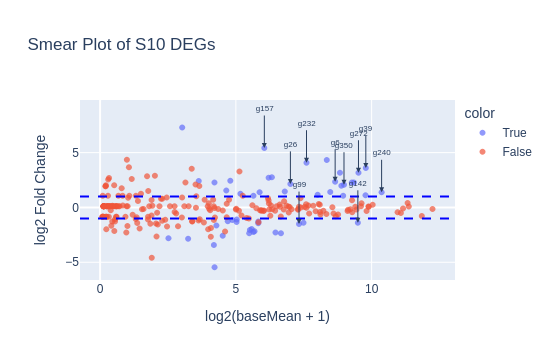

In [17]:
import plotly.express as px
import pandas as pd
import numpy as np

# Prepare data for plotting
deg_S10["logCPM"] = np.log2(deg_S10["baseMean"] + 1)  # Approximate logCPM
deg_S10_filtered["logCPM"] = np.log2(deg_S10_filtered["baseMean"] + 1)

# Create Plotly scatter plot
fig = px.scatter(
    deg_S10, 
    x="logCPM", 
    y="log2FoldChange", 
    color=(deg_S10["padj"] < 0.05) & (deg_S10["log2FoldChange"].abs() > 1),
    title="Smear Plot of S10 DEGs",
    labels={"logCPM": "log2(baseMean + 1)", "log2FoldChange": "log2 Fold Change"},
    color_continuous_scale=["grey", "red"],
    opacity=0.7
)

# Add the top 10 gene labels
for i in range(min(10, len(deg_S10_filtered))):
    fig.add_annotation(
        x=deg_S10_filtered.iloc[i]["logCPM"],
        y=deg_S10_filtered.iloc[i]["log2FoldChange"],
        text=deg_S10_filtered.iloc[i][0],
        showarrow=True,
        arrowhead=2,
        ax=0,
        ay=-40,
        font=dict(size=8)
    )

# Add horizontal lines at logFC ±1
fig.add_hline(y=1, line_dash="dash", line_color="blue")
fig.add_hline(y=-1, line_dash="dash", line_color="blue")

# Show the figure
fig.show()


We can also create a heatmap with the log2 read counts of the selected differentially expressed genes so that we can visualise the differences in normalized counts between the Control and the Treatment samples.

The genes are ordered by the FDR value. 

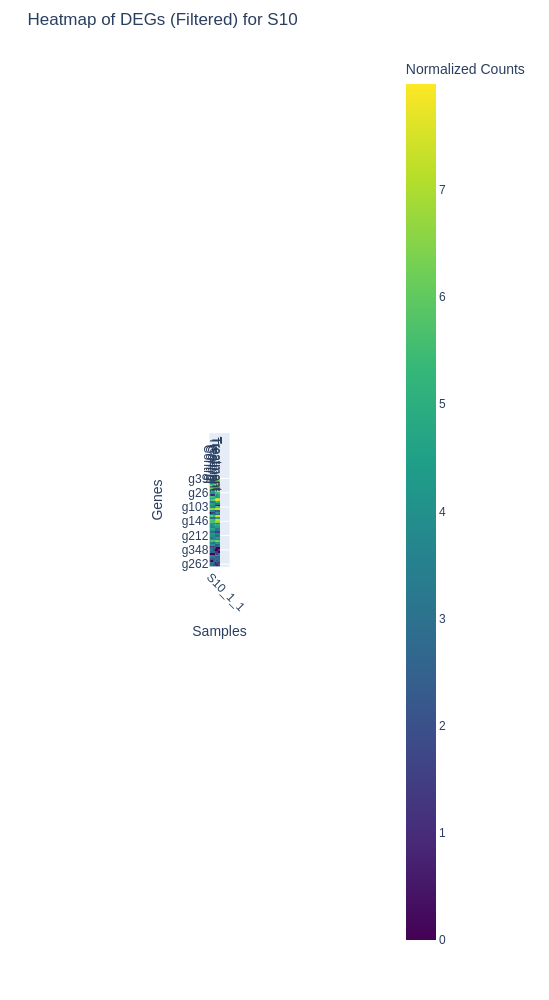

In [18]:
import plotly.express as px


# Select the genes that passed the filtering (DEGs) from the pseudo-normalized counts
selected_genes = deg_S10_filtered.gene_ID.values
heatmap_counts = pd.DataFrame(pds.preprocessing.deseq2_norm(dds.X)[0][:6,:], index=dds.obs_names[:6], columns=dds.var_names)
heatmap_counts =  heatmap_counts[selected_genes].T   # select first 6 samples
annot_col = pd.DataFrame({"Condition": ["Control"]*3 + ["Treatment"]*3}, index=dds.obs_names[:6])


# Create a heatmap
fig = px.imshow(np.log1p(heatmap_counts),
                labels={'x': "Samples", 'y': "Genes", 'color': 'Normalized Counts'},
                x=heatmap_counts.columns, 
                y=selected_genes,
                color_continuous_scale='Viridis')

fig.update_layout(
    title="Heatmap of DEGs (Filtered) for S10",
    height=1000,    # Increase overall height
    width=1800,     # Increase overall width
    autosize=True,  # Auto-sizing to fit the data
    xaxis=dict(
        scaleanchor="y",  # Keeps the aspect ratio square
        tickangle=45,     # Optional: rotate axis labels for better visibility
    ),
#    yaxis=dict(
#        scaleanchor="x",  # Keeps the aspect ratio square
#    ),
    margin=dict(t=50, r=50, b=50, l=50)  # Optional: add margins for better spacing
)


# Add annotations for the conditions (Control vs Treatment)
for i, col in enumerate(heatmap_counts.columns):
    fig.add_annotation(
        x=i,
        y=-8,
        text=annot_col["Condition"].iloc[i],
        showarrow=False,
        font=dict(size=12),
        textangle=90,    
        align="center"
    )


fig.update_layout(title="Heatmap of DEGs (Filtered) for S10")#, height=600, width=800)
fig.show()


## DEGs for White clover Tienshan Treatment vs Control
We can do this using the same functions as above and changing the contrast.

This time we will directly filter the differentially expressed genes using the same parameters as for the S10 samples.

We can now plot a Venn diagram with the DEGs for the two genotypes in order to observe the number of common and specific differentially expressed genes between the two genotypes as response to the cold exposure. You can see that a high percentage of the identified genes are common for the two genotypes, while each genotype has also specific genes.

In [20]:
# Perform statistical test for Tienshan_Treatment vs Tienshan_Control
stat_Ti = DeseqStats(dds, contrast=["Group", "Tienshan_Treatment", "Tienshan_Control"], n_cpus=2)
stat_Ti.summary()

# Extract results sorted by adjusted p-value
deg_Ti = stat_Ti.results_df.sort_values("padj")

# Filter by adjusted p-value and log2 fold change
DEG_Ti_filtered = deg_Ti[(deg_Ti["padj"] < 0.05) & (deg_Ti["log2FoldChange"].abs() > 1)].copy()
DEG_Ti_filtered.reset_index(inplace=True)
DEG_Ti_filtered.rename(columns={"index": "gene_ID"}, inplace=True)

print(DEG_Ti_filtered.head())
print(f"Nr of DEGs (Tienshan): {len(DEG_Ti_filtered)}")

Running Wald tests...


Log2 fold change & Wald test p-value: Group Tienshan_Treatment vs Tienshan_Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
g175   203.177414       -0.238922  0.149157 -1.601814  0.109197  0.210594
g176    17.580091       -1.050225  0.566677 -1.853304  0.063839  0.147696
g178     0.647614        1.137870  3.057081  0.372208  0.709738       NaN
g180  2642.862488        0.818180  0.321691  2.543369  0.010979  0.037054
g181   553.192011       -0.577479  0.157121 -3.675383  0.000237  0.001360
...           ...             ...       ...       ...       ...       ...
g169     0.223759       -0.130217  4.919521 -0.026469  0.978883       NaN
g170     0.102188       -1.092009  4.729264 -0.230905  0.817389       NaN
g171     0.788091        0.831575  4.619218  0.180025  0.857133       NaN
g172     2.417607       -0.140977  1.132306 -0.124504  0.900916  0.943750
g173    97.041848        0.332290  0.292340  1.136656  0.255682  0.397095

[267 rows x 6 columns]
  gen

... done in 8.52 seconds.



## DEGs for S10+Tienshan Treatment vs Control w/o genotype effects

Until now we tested for DEGs specific for each of the two genotypes under cold treatment. We can also run a test where we ignore the genotype and just test for the differences in the cold response.
<br>
Consider the counts for both genotypes as a single dataset using the previously created contrast "S10_Tienshan". 
<br>
* Do the results look different compared with the previous tests?

In [21]:
# Second DeseqDataSet ignoring genotype — tests Treatment vs Control across both genotypes
dds2 = DeseqDataSet(
    counts=read_counts_filtered.astype(int).T,
    metadata=metadata[["Condition", "Genotype", "Group"]],
    design="~Condition",
    inference=inference
)
dds2

AnnData object with n_obs × n_vars = 12 × 267
    obs: 'Condition', 'Genotype', 'Group'
    obsm: 'design_matrix'

In [22]:
dds2.obs

,Condition,Genotype,Group
Sample,,,
S10_1_1,Control,S10,S10_Control
S10_1_2,Control,S10,S10_Control
S10_1_3,Control,S10,S10_Control
S10_2_1,Treatment,S10,S10_Treatment
S10_2_2,Treatment,S10,S10_Treatment
S10_2_3,Treatment,S10,S10_Treatment
TI_1_1,Control,Tienshan,Tienshan_Control
TI_1_2,Control,Tienshan,Tienshan_Control
TI_1_3,Control,Tienshan,Tienshan_Control


In [23]:
dds2.obsm['design_matrix']

,Intercept,Condition[T.Treatment]
Sample,,
S10_1_1,1.0,0
S10_1_2,1.0,0
S10_1_3,1.0,0
S10_2_1,1.0,1
S10_2_2,1.0,1
S10_2_3,1.0,1
TI_1_1,1.0,0
TI_1_2,1.0,0
TI_1_3,1.0,0


In [24]:
dds2.deseq2()

# Perform statistical test for S10_Treatment vs S10_Control
stat_genotype = DeseqStats(dds2, contrast=["Condition", "Treatment", "Control"], n_cpus=2)
stat_genotype.summary()

# Extract results sorted by adjusted p-value (like topTags)
deg_genotype = stat_genotype.results_df.sort_values("padj")


Fitting size factors...
... done in 0.00 seconds.

Fitting dispersions...


Using None as control genes, passed at DeseqDataSet initialization


... done in 0.22 seconds.

Fitting dispersion trend curve...
... done in 0.01 seconds.

Fitting MAP dispersions...
... done in 0.25 seconds.

Fitting LFCs...
... done in 0.18 seconds.

Calculating cook's distance...
... done in 0.00 seconds.

Replacing 0 outlier genes.

Running Wald tests...


Log2 fold change & Wald test p-value: Condition Treatment vs Control
         baseMean  log2FoldChange     lfcSE      stat    pvalue      padj
g175   203.177414       -0.052391  0.177766 -0.294720  0.768207  0.951365
g176    17.580091       -0.659558  0.483840 -1.363173  0.172828  0.452403
g178     0.647614        1.291357  2.280091  0.566362  0.571148  0.884445
g180  2642.862488        0.318850  0.416662  0.765247  0.444124  0.790542
g181   553.192011       -0.478412  0.228632 -2.092494  0.036394  0.156731
...           ...             ...       ...       ...       ...       ...
g169     0.223759        0.467223  3.265081  0.143097  0.886214  0.951365
g170     0.102188       -0.494569  3.402798 -0.145342  0.884441  0.951365
g171     0.788091        0.426957  2.899259  0.147264  0.882923  0.951365
g172     2.417607        0.750189  0.759003  0.988388  0.322963  0.710854
g173    97.041848        0.306162  0.209863  1.458864  0.144603  0.422412

[267 rows x 6 columns]


... done in 0.05 seconds.



In [25]:
# Filter by FDR < 0.05 and absolute log2FC > 1
DEG_cond_filtered = deg_genotype[( deg_genotype["padj"] < 0.05) & ( deg_genotype["log2FoldChange"].abs() > 1)].copy()

# Reset index to expose gene IDs as a column
DEG_cond_filtered = DEG_cond_filtered.reset_index().rename(columns={"index": "gene_ID"})

# Show first few rows
print(DEG_cond_filtered.head())

# Print number of DEGs
print("Nr of differentially expressed genes:")
print(len(DEG_cond_filtered))


  gene_ID    baseMean  log2FoldChange     lfcSE       stat        pvalue  \
0    g272  730.949464        3.267071  0.313377  10.425365  1.899279e-25   
1    g269  178.906527       -1.660385  0.175202  -9.476991  2.617207e-21   
2    g157   65.179508        4.863199  0.538719   9.027343  1.758912e-19   
3    g232  193.277430        3.499050  0.447324   7.822183  5.191496e-15   
4    g101  455.249347        3.540633  0.460513   7.688450  1.489277e-14   

           padj  
0  5.071074e-23  
1  3.493971e-19  
2  1.565431e-17  
3  3.465324e-13  
4  7.952739e-13  
Nr of differentially expressed genes:
42


In [ ]:
#until here

In [27]:
/opt/ install matplotlib_venn

/bin/bash: line 1: pip: command not found


Plot the results from the 3 tests in a Venn diagram to visualize the number of common and unique genes

In [26]:
from matplotlib_venn import venn3
import matplotlib.pyplot as plt

set_S10 = set(deg_S10_filtered['gene_ID'])
set_Ti = set(DEG_Ti_filtered['gene_ID'])
set_cond = set(DEG_cond_filtered['gene_ID'])

plt.figure(figsize=(7, 7))
venn = venn3(
    [set_S10, set_Ti, set_cond],
    set_labels=('S10', 'Tienshan', 'S10+Tienshan'),
    set_colors=('cornflowerblue', 'yellowgreen', 'thistle'),
    alpha=0.7
)
for text in venn.set_labels:
    text.set_fontweight('bold')
    text.set_fontsize(12)
plt.title("Venn Diagram of DEG overlap (3 contrasts)", fontsize=14)
plt.show()

ModuleNotFoundError: No module named 'matplotlib_venn'

## Explore DGE results

### Select the genes which appear only in the analysis using both genotypes for further examination.

We use pandas boolean indexing to keep only the genes that are unique to the combined analysis — i.e., not present in either the S10-only or Tienshan-only results.

In [ ]:
# Keep only genes unique to the combined analysis (not found in S10-only or Ti-only results)
S10_Ti_unique = DEG_cond_filtered[
    ~DEG_cond_filtered['gene_ID'].isin(deg_S10_filtered['gene_ID']) &
    ~DEG_cond_filtered['gene_ID'].isin(DEG_Ti_filtered['gene_ID'])
].copy()
S10_Ti_unique

In [ ]:
read_counts_reset = read_counts.reset_index().rename(columns={"index": "gene_ID"})
S10_Ti_unique_counts = S10_Ti_unique[['gene_ID', 'log2FoldChange', 'padj']].merge(
    read_counts_reset, on='gene_ID'
)
S10_Ti_unique_counts

### Linking the genes selected as differentially expressed back to the raw read counts

How do the counts look for these genes, does it make sense that they are differentially expressed only when using the two genotypes?

In [ ]:
Functional_annotations = pd.read_csv("../Data/Clover_Data/Functional_Annotations.txt", sep="\t")
S10_Ti_unique_FA = S10_Ti_unique[['gene_ID', 'log2FoldChange', 'padj']].merge(
    Functional_annotations, on='gene_ID'
)
S10_Ti_unique_FA

In [ ]:
import matplotlib.pyplot as plt

plt.figure(figsize=(8, 4))
plt.hist(deg_S10['padj'].dropna(), bins=200, range=(0, 0.1), color='steelblue', edgecolor='black')
plt.xlabel("padj (adjusted p-value)")
plt.title("")
plt.tight_layout()
plt.show()

In [ ]:
plt.figure(figsize=(8, 4))
plt.hist(deg_S10['log2FoldChange'].dropna(), bins=50, range=(-6, 6), color='steelblue', edgecolor='black')
plt.xlabel("log2FoldChange")
plt.title("")
plt.tight_layout()
plt.show()

In [ ]:
import os
os.makedirs("DEG_Output_tables", exist_ok=True)

In [ ]:
read_counts_reset = read_counts.reset_index().rename(columns={"index": "gene_ID"})
ti_cols = ['gene_ID'] + list(read_counts.columns[6:12])  # Ti samples: TI_1_1 through TI_2_3

DEG_Ti_counts_FA = (
    DEG_Ti_filtered[['gene_ID', 'log2FoldChange', 'padj']]
    .merge(read_counts_reset[ti_cols], on='gene_ID')
    .merge(Functional_annotations, on='gene_ID')
)

DEG_Ti_counts_FA.to_csv(
    "DEG_Output_tables/Ti_Treatment_Control_DGE.txt",
    sep="\t", index=False
)

DEG_Ti_counts_FA.head(10)

In [ ]:
DEG_Ti_up = DEG_Ti_counts_FA[DEG_Ti_counts_FA['log2FoldChange'] > 0]
print("Nr of upregulated genes:")
print(len(DEG_Ti_up))

DEG_Ti_down = DEG_Ti_counts_FA[DEG_Ti_counts_FA['log2FoldChange'] < 0]
print("Nr of downregulated genes:")
print(len(DEG_Ti_down))

:::{.callout-tip title="Task"}
*   Based on the results obtained in the analysis so far, would you change the cut-off for the FDR and logFC to be more strict or more permissive? Look back at the raw counts for different FDR and logFC values and set the thresholds as you find appropriate.

You can also plot histograms with the FDR and logFC values. 

* Separate the upregulated and downregulated genes for each genotype and append functional annotations to them. 
* Identify the genes that are commonly upregulated in S10 and Tienshan samples and the uniquely upregulated genes for each genotype.
* Why do you think some of the proteins appear in duplicates? <br>

To answer these questions, it may be convenient to save summary tables from R and open them in excel. See the code below for examples of how to do this. Files can be downloaded by right-clicking on the file name.

If you are familiar with R functions, you are welcome to use those for counting.
:::



Example for filtering and counting the Up/Down genes. You can easily filter using pandas boolean indexing on the `log2FoldChange` column.

You can use the "inner_join" and the "anti_join" functions from the dplyr package to select the common and unique genes for each genotype:

`example_file_joined <- inner_join(file1, file2, by="gene_ID")`
:::

**End of the task**

---